# Common Libraries

In [1]:
import os, sys, shutil, mediapy
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pylab as plt
from scipy.interpolate import interp1d

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Custom Libraries

In [2]:
sys.path.append("/home/seojin/Seojin_commonTool/Module")
from biomechanics_util import get_mujoco_joints
from video_tool import save_video

# Params

In [3]:
model_path = "/mnt/sdb2/DeepProprioception/Projects/DP01_mri/Myosuite/Model/scaled_model_cvt3_mocap.xml"
qpos_path = "/mnt/sdb2/DeepProprioception/Projects/DP01_mri/Myosuite/Model/IK_files/trial1_IK_qpos.csv"

simulation_time_interval = 1/30 # 0.001# 1/30 # 0.0001

# Initialize model

In [4]:
n_sim_perSecond = 1 / simulation_time_interval
model = mujoco.MjModel.from_xml_path(model_path)
model.opt.timestep = simulation_time_interval
model.opt.gravity = [-9.81, 0, 0]

joint_names = [mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, idx) for idx in range(model.njnt)]
dependent_joint_names, independent_joint_names = get_mujoco_joints(model_path)

# Load data

In [5]:
qpos_data = pd.read_csv(qpos_path, index_col = [0])

qvel_data = qpos_data[joint_names].diff(1) / qpos_data["times"].diff(1).iloc[1]
qvel_data = qvel_data.fillna(0)
qvel_data.insert(0, "times", qpos_data["times"])

qacc_data = qvel_data[joint_names].diff(1) / qpos_data["times"].diff(1).iloc[1]
qacc_data = qacc_data.fillna(0)
qacc_data.insert(0, "times", qpos_data["times"])

In [6]:
def downsampling(df, simulation_time_interval):
    df = df.copy()
    x = df["times"].values
    y = df.drop(columns = ["times"]).values
    
    new_times = np.arange(x.min(), x.max() + 1e-7, simulation_time_interval)
    f = interp1d(x, y, kind = "cubic", axis = 0, fill_value = "extrapolate")
    new_y = f(new_times)
    new_df = pd.DataFrame(new_y, columns = df.columns.drop("times"))
    new_df.insert(0, "times", new_times)
    return new_df
    
qpos_data = downsampling(qpos_data, simulation_time_interval)
qvel_data = downsampling(qvel_data, simulation_time_interval)
qacc_data = downsampling(qacc_data, simulation_time_interval)

# Constants

In [7]:
# Model constants
n_joint = len(joint_names)

# Joint indexing
joint_map = {}
for joint_name in joint_names:
    jnt_id = model.joint(joint_name).id
    qpos_idx = model.jnt_qposadr[jnt_id]
    dof_idx = model.jnt_dofadr[jnt_id]

    kp = 1000 if joint_name in independent_joint_names else 0 # Stiffness
    kv = 50 # 2 * np.sqrt(kp) if joint_name in independent_joint_names else 0 # Damping

    joint_map[joint_name] = {
        "joint_id" : jnt_id,
        "qposadr" : qpos_idx,
        "dofadr" : dof_idx,
        "kp" : kp,
        "kv" : kv,
    }

# Set initial pose

In [8]:
# Initialize pose
mj_data = mujoco.MjData(model)
mj_data.qpos = qpos_data.iloc[0][joint_names].values
mujoco.mj_forward(model, mj_data)

# Renderer

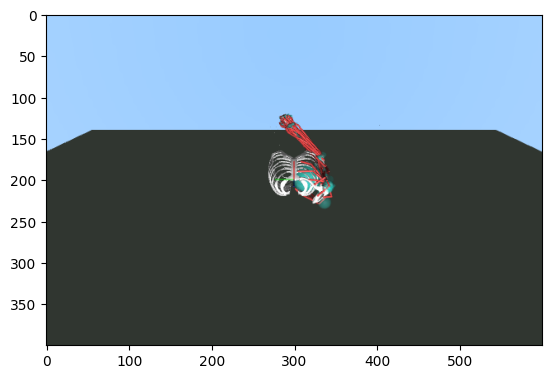

In [9]:
# Renderer
renderer = mujoco.Renderer(model, height=400, width=600)
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_WORLD

# Camera
camera = mujoco.MjvCamera()
camera.azimuth = 0
camera.elevation = -110
camera.distance = 2.0

# Initial render
renderer.update_scene(mj_data, camera=camera, scene_option=scene_option)
plt.imshow(renderer.render())

# Simulation

In [10]:
kps = np.array([joint_map[joint_name]["kp"] for joint_name in joint_names])
kvs = np.array([joint_map[joint_name]["kv"] for joint_name in joint_names])

In [11]:
# Simulation constants
maximum_exp_time = qpos_data["times"].max()
n_simulations = int(np.round(maximum_exp_time / simulation_time_interval, 1))

joint_ids = [joint_map[name]["joint_id"] for name in joint_names]
joint_ids = np.array(joint_ids)

# Initialize start pose
mj_data = mujoco.MjData(model)
mj_data.qpos = qpos_data.iloc[0][joint_names].values
mujoco.mj_forward(model, mj_data)

# Pixel
pixels = np.zeros((n_simulations, renderer.height, renderer.width, 3), dtype = np.uint8)

# Joint history
simulation_qpos = pd.DataFrame(np.zeros((n_simulations, n_joint + 1)))
simulation_qpos.columns = ["times"] + joint_names

simulation_qvel = pd.DataFrame(np.zeros((n_simulations, n_joint + 1)))
simulation_qvel.columns = ["times"] + joint_names

# Force history
simulation_qforces = pd.DataFrame(np.zeros((n_simulations, n_joint + 1)))
simulation_qforces.columns = ["times"] + joint_names

# Error history
simulation_qpos_errors = pd.DataFrame(np.zeros((n_simulations, n_joint + 1)))
simulation_qpos_errors.columns = ["times"] + joint_names

# Simulation
for simulation_i in tqdm(range(n_simulations)):
    simulation_time = simulation_i * simulation_time_interval
    
    # Current
    current_qpos = mj_data.qpos.copy()
    current_qvel = mj_data.qvel.copy()

    # Goal
    goal_i = np.searchsorted(qpos_data["times"], simulation_time)
    goal_qpos = qpos_data.iloc[goal_i][joint_names].values
    goal_qvel = qvel_data.iloc[goal_i][joint_names].values

    error_q = np.zeros_like(goal_qpos)
    error_q[joint_ids] = goal_qpos - current_qpos[joint_ids]
    
    """
    # PD control
    error_q = np.zeros_like(goal_qpos)
    error_q[joint_ids] = goal_qpos - current_qpos[joint_ids]

    error_v = np.zeros_like(goal_qvel)
    error_v[joint_ids] = goal_qvel - current_qvel[joint_ids]
    
    qforces = kps * error_q + kvs * error_v
    """
    
    # ID
    data_copy = mujoco.MjData(model)
    data_copy.qpos[:] = current_qpos
    data_copy.qvel[:] = current_qvel
    mujoco.mj_forward(model, data_copy)

    qvel_to_goal = (goal_qpos - current_qpos) / model.opt.timestep
    data_copy.qacc[:] = (qvel_to_goal - current_qvel) / model.opt.timestep

    #model.opt.disableflags += mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    mujoco.mj_inverse(model, data_copy)
    #model.opt.disableflags -= mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    
    # Apply force
    qforces = data_copy.qfrc_inverse.copy()
    mj_data.qfrc_applied[:] = qforces
    
    # Record joints history
    simulation_qpos.iloc[simulation_i] = np.hstack([simulation_time, current_qpos])
    simulation_qvel.iloc[simulation_i] = np.hstack([simulation_time, current_qvel])

    # Record forces
    simulation_qforces.iloc[simulation_i] = np.hstack([simulation_time, qforces])
    
    # Record Errors
    simulation_qpos_errors.iloc[simulation_i] = np.hstack([simulation_time, error_q])
    
    # Forward dyanmics
    mujoco.mj_step(model, mj_data)
    
    # Rendering
    renderer.update_scene(mj_data, camera = camera, scene_option = scene_option)
    pixels[simulation_i] = renderer.render()

100%|██████████| 39/39 [00:00<00:00, 148.76it/s]


In [12]:
print("qfrc_bias:", data_copy.qfrc_bias)
print("qfrc_passive:", data_copy.qfrc_passive)
print("qfrc_constraint:", data_copy.qfrc_constraint)
print("qfrc_inverse:", data_copy.qfrc_inverse)

qfrc_bias: [ 1.33248474e+01 -1.16869695e+01 -1.45239030e+01 -3.59040863e+01
 -4.34138447e+01  3.93943668e+01  2.58168853e+01  2.34422544e+01
  4.69703758e+01 -3.24288705e+01 -1.28592648e+01  4.41194806e+01
 -1.38504649e+01 -1.46149368e+01  1.80207054e+00  1.99164626e-02
  1.12451186e+00 -1.39169769e+00 -1.29754482e+00 -1.35406716e+00]
qfrc_passive: [-0.01784773 -0.00229912  0.00733903  0.02289025  0.01214279  0.02111816
 -0.00109369 -0.01396854 -0.00216522 -0.00213337 -0.00321965  0.03227709
 -0.01197338 -0.13685302  0.07143484  0.04105929 -0.04817391  0.02239604
  0.13763537 -0.08708098]
qfrc_constraint: [ 2.75162381e+04 -9.76859714e+04 -3.64269802e+04 -8.81792512e+04
 -1.56072897e+04  3.15926967e+03 -1.42630583e+03 -1.92429677e+04
 -1.39712929e+04 -2.63168305e+03 -1.52546633e+06  2.74595425e+04
 -1.52537301e+06 -3.55007861e+02 -1.62703871e+01 -5.31820628e+00
 -4.65868267e+01  2.99743467e+01  9.34374568e+01 -6.14268558e+00]
qfrc_inverse: [-2.73526326e+04  9.75761825e+04  3.63345741e+0

In [13]:
contype="0"
conaffinity="0"

In [14]:
for i in range(data_copy.ncon):
    c = data_copy.contact[i]
    if c.dist < -0.005:
        g1 = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_GEOM, c.geom1)
        g2 = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_GEOM, c.geom2)
        print(i, c.dist, c.geom1, g1, c.geom2, g2)

0 -0.0054825618682939545 1 thorax_geom_1 5 clavicle_geom_1
6 -0.021511661332663932 32 TRI_cylinder 1 thorax_geom_1
11 -0.008740744970145696 1 thorax_geom_1 51 ulna_geom_1
13 -0.005166205481091593 6 scapula_geom_1 12 humerus_geom_1
14 -0.04765472176553633 7 Deltoid2_ellipsoid 12 humerus_geom_1
15 -0.027447125645917697 7 Deltoid2_ellipsoid 13 DELT1hh_ellipsoid
17 -0.035086120449077766 7 Deltoid2_ellipsoid 16 SUPSP_ellipsoid
18 -0.03951390338258429 7 Deltoid2_ellipsoid 17 INFSP_and_TMIN_hum_head_ellipsoid
19 -0.047689083070602045 7 Deltoid2_ellipsoid 18 infsp_new_cylinder
20 -0.0363926582745054 7 Deltoid2_ellipsoid 19 SUBSCAP_ellipsoid
21 -0.03927337169734745 7 Deltoid2_ellipsoid 20 LIGhh_s_ellipsoid
22 -0.03767386691656316 7 Deltoid2_ellipsoid 21 LIGhh_mi_ellipsoid
23 -0.04605363914526345 7 Deltoid2_ellipsoid 22 TMINhum_cylinder
24 -0.012516718552799747 7 Deltoid2_ellipsoid 23 TMAJ_LAThum_cylinder
25 -0.020021615306357425 7 Deltoid2_ellipsoid 24 PEC12hum_cylinder
26 -0.03639744056027562 

In [15]:
save_video(pixels, fps = int(1 / simulation_time_interval), output_path = "/mnt/ext1/seojin/temp/arm_sim.mp4", is_progress_bar = True)

MoviePy - Building video /mnt/ext1/seojin/temp/arm_sim.mp4.
MoviePy - Writing video /mnt/ext1/seojin/temp/arm_sim.mp4



MoviePy - Done !
MoviePy - video ready /mnt/ext1/seojin/temp/arm_sim.mp4
save: /mnt/ext1/seojin/temp/arm_sim.mp4


In [16]:
mediapy.show_video(pixels, fps = 30)

This browser does not support the video tag.


# QPos plot

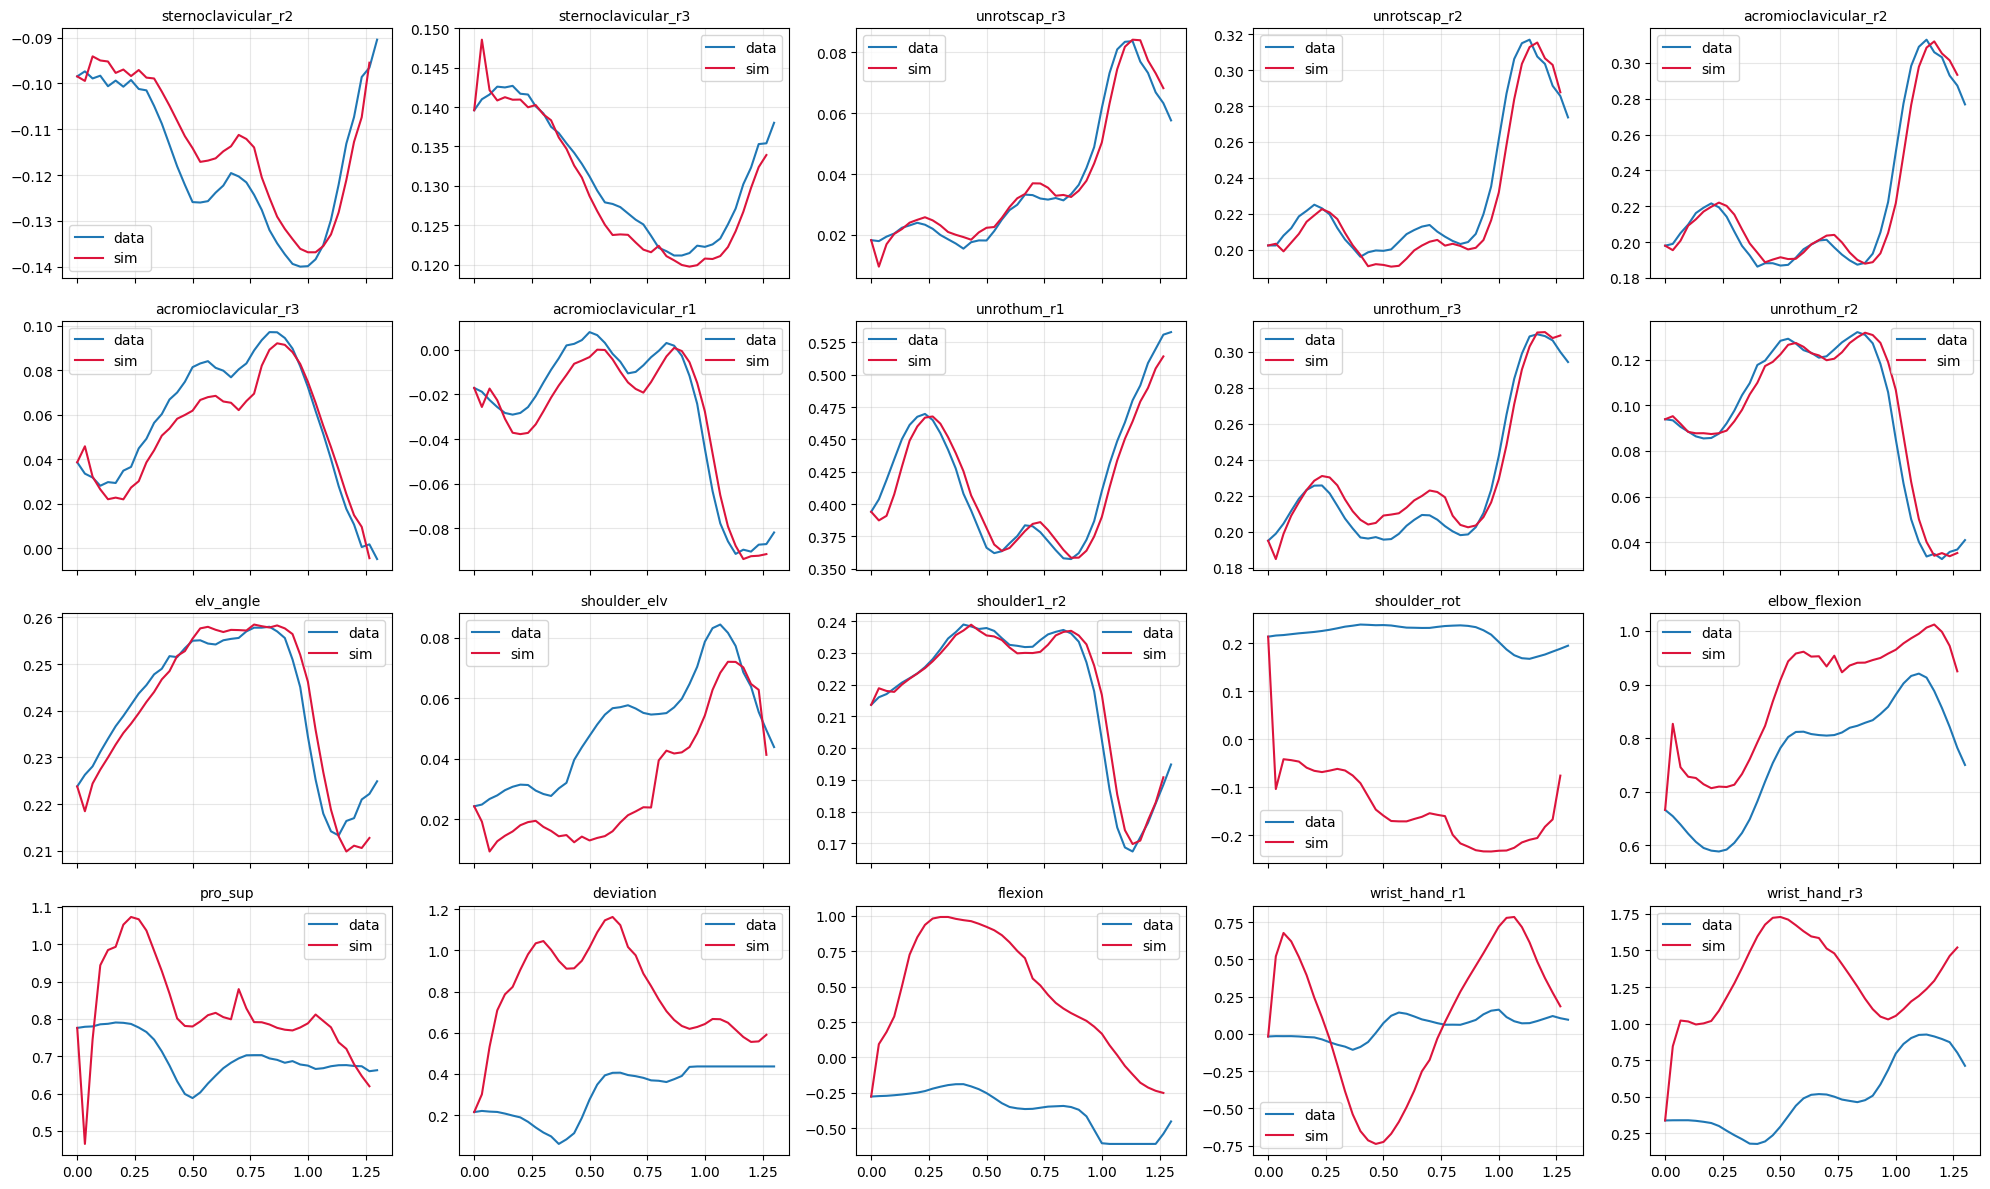

In [17]:
# Plot parameters
n_cols = 5
n_rows = (len(joint_names) + n_cols - 1) // n_cols

# Plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=True)
axes = axes.flatten()
for i, joint_name in enumerate(joint_names):
    ax = axes[i]
    ax.plot(qpos_data["times"], qpos_data[joint_name], label = "data")
    ax.plot(simulation_qpos["times"], simulation_qpos[joint_name], color = "crimson", lw = 1.5, label = "sim")
    ax.set_title(joint_name, fontsize = 10)
    ax.grid(alpha = 0.3)
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Error plot

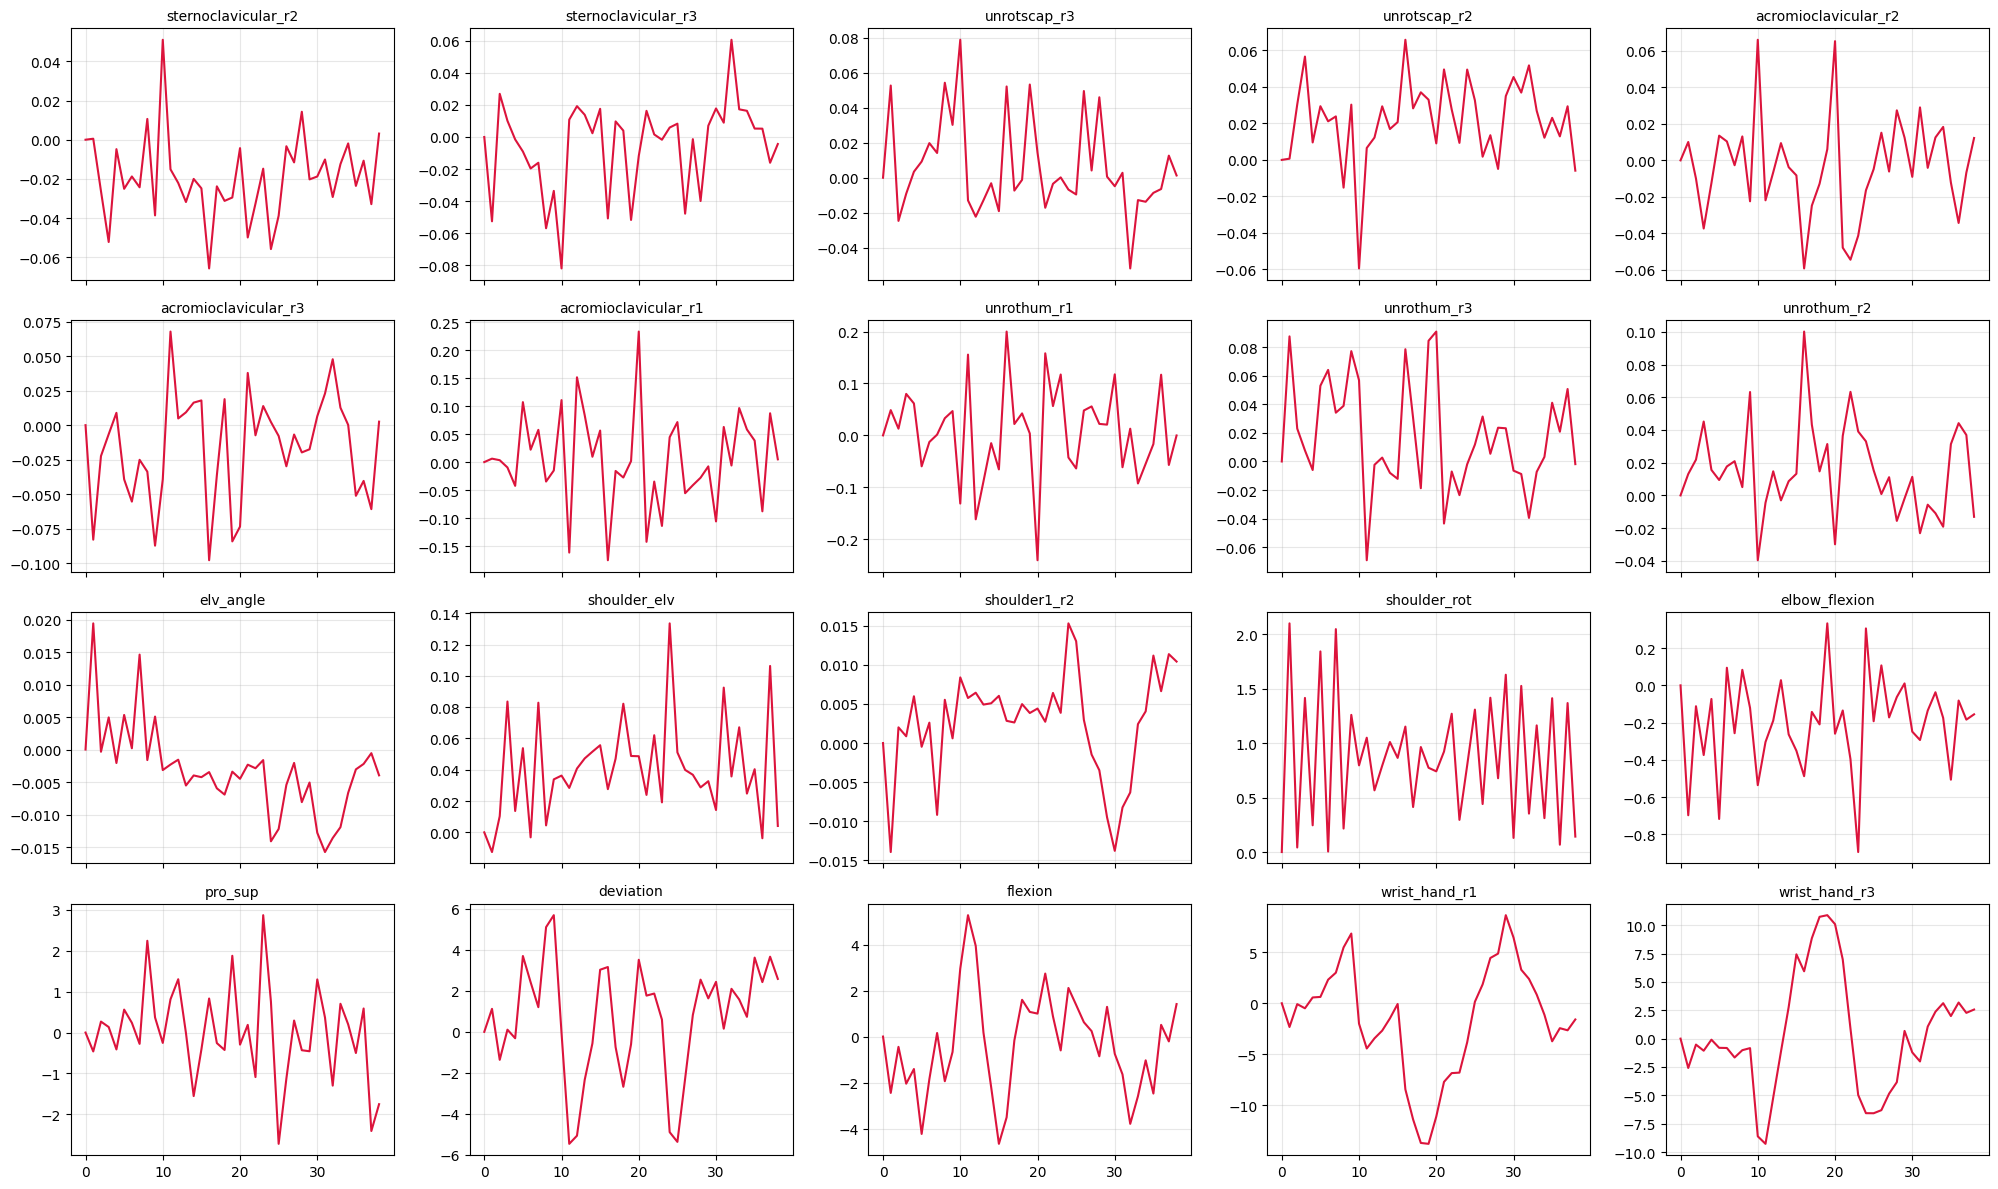

In [16]:
# Plot parameters
n_cols = 5
n_rows = (len(joint_names) + n_cols - 1) // n_cols

# Plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=True)
axes = axes.flatten()
for i, joint_name in enumerate(joint_names):
    ax = axes[i]
    ax.plot(simulation_qpos_errors[joint_name], color='crimson', lw=1.5)
    ax.set_title(joint_name, fontsize=10)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Force plot

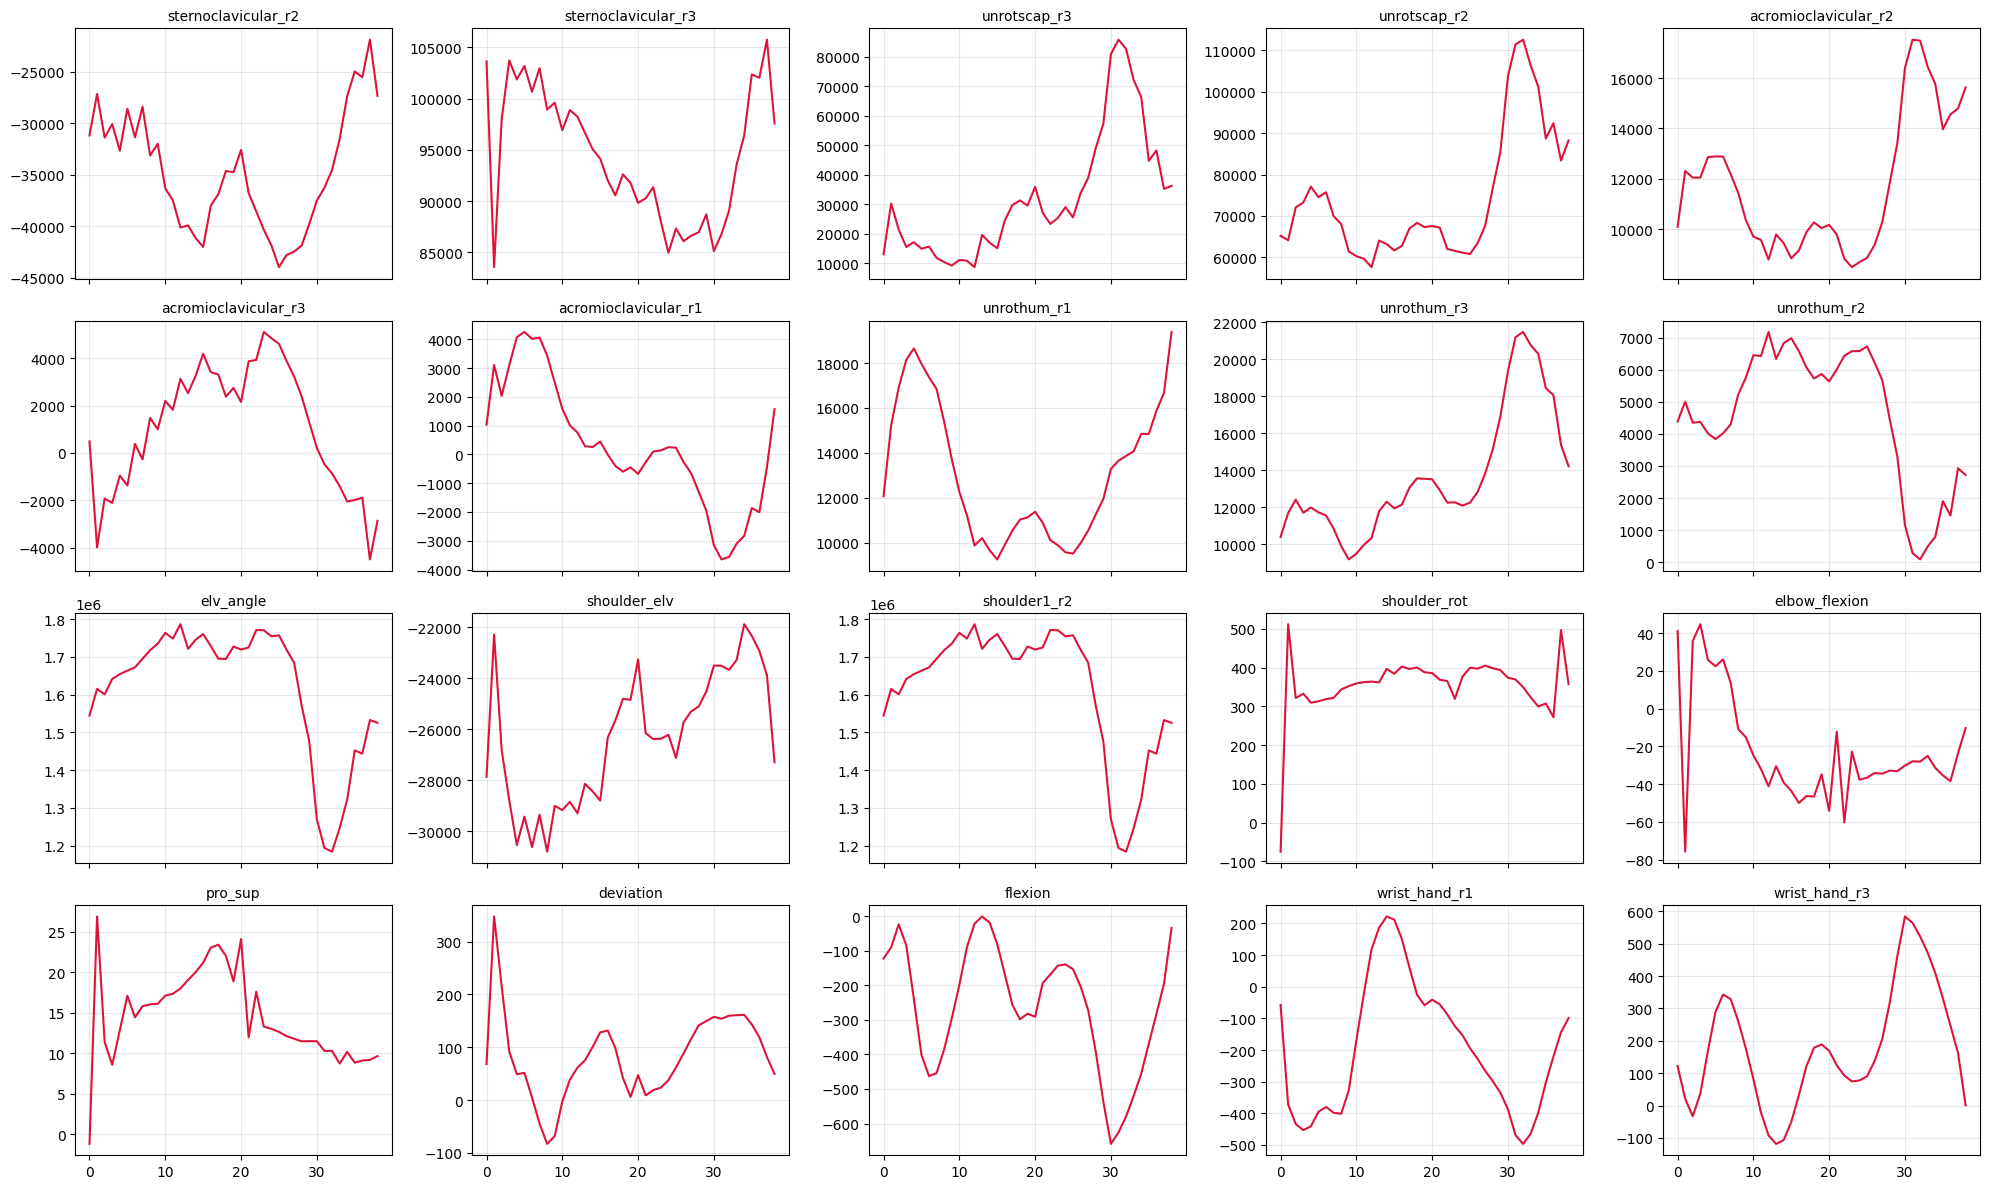

In [18]:
# Plot parameters
n_cols = 5
n_rows = (len(joint_names) + n_cols - 1) // n_cols

# Plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=True)
axes = axes.flatten()
for i, joint_name in enumerate(joint_names):
    ax = axes[i]
    ax.plot(simulation_qforces[joint_name], color = "crimson", lw=1.5)
    ax.set_title(joint_name, fontsize=10)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()